# 04 — Gráficas candidatas para el tablero

Lee `df_cut.csv` (empleo formal, 2005-2025) y genera **8 gráficas Plotly interactivas** listas para seleccionar cuáles van al dashboard Quarto.

Cada gráfica tiene:
- Título con la **conclusión** (no solo el tema)
- Paleta de colores consistente
- Anotaciones donde hay hallazgos clave
- Exportación a HTML individual por si se necesita

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Rutas
RAIZ = Path('..').resolve()
RUTA_CSV = RAIZ / 'datos' / 'analisis' / 'df_cut.csv'
RUTA_SALIDA = RAIZ / 'dashboard'
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

# Paleta consistente con notebook 03
COLOR_H = '#378ADD'
COLOR_M = '#D4537E'
COLOR_ROJO = '#d62728'
COLOR_VERDE = '#2ca02c'
COLOR_GRIS = '#888888'
COLOR_AMARILLO = '#f0ad4e'

# Cargar el dataset maestro
df = pd.read_csv(RUTA_CSV, encoding='utf-8-sig')
print(f'Dataset cargado: {len(df):,} registros, {df["anio"].min()}-{df["anio"].max()}')
print(f'Estados: {df["entidad"].nunique()}, Sectores: {df["sector"].nunique()}')

# Helper: media ponderada
def wmean(sub, col='mediana_ing_hora', w='poblacion_ocupada'):
    mask = sub[col].notna() & sub[w].notna() & (sub[w] > 0)
    if mask.sum() == 0: return np.nan
    return np.average(sub.loc[mask, col], weights=sub.loc[mask, w])

def brecha_grupo(sub):
    h = sub[sub['sexo'] == 'Hombre']
    m = sub[sub['sexo'] == 'Mujer']
    ih = wmean(h)
    im = wmean(m)
    if pd.isna(ih) or pd.isna(im) or ih == 0: return {'ih': ih, 'im': im, 'brecha': np.nan}
    return {'ih': round(ih,2), 'im': round(im,2), 'brecha': round((ih-im)/ih*100, 1)}

Dataset cargado: 226,798 registros, 2005-2025
Estados: 32, Sectores: 11


In [18]:
# Rutas DF_SI
RAIZ = Path('..').resolve()
RUTA_CSV = RAIZ / 'datos' / 'analisis' / 'df_cut_si.csv'
RUTA_SALIDA = RAIZ / 'dashboard'
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

# Paleta consistente con notebook 03
COLOR_H = '#378ADD'
COLOR_M = '#D4537E'
COLOR_ROJO = '#d62728'
COLOR_VERDE = '#2ca02c'
COLOR_GRIS = '#888888'
COLOR_AMARILLO = '#f0ad4e'

# Cargar el dataset maestro
df = pd.read_csv(RUTA_CSV, encoding='utf-8-sig')
print(f'Dataset cargado: {len(df):,} registros, {df["anio"].min()}-{df["anio"].max()}')
print(f'Estados: {df["entidad"].nunique()}, Sectores: {df["sector"].nunique()}')

Dataset cargado: 226,798 registros, 2005-2025
Estados: 32, Sectores: 11


In [31]:
# Rutas DF_NO 
RAIZ = Path('..').resolve()
RUTA_CSV = RAIZ / 'datos' / 'analisis' / 'df_cut_no.csv'
RUTA_SALIDA = RAIZ / 'dashboard'
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

# Paleta consistente con notebook 03
COLOR_H = '#378ADD'
COLOR_M = '#D4537E'
COLOR_ROJO = '#d62728'
COLOR_VERDE = '#2ca02c'
COLOR_GRIS = '#888888'
COLOR_AMARILLO = '#f0ad4e'

# Cargar el dataset maestro
df = pd.read_csv(RUTA_CSV, encoding='utf-8-sig')
print(f'Dataset cargado: {len(df):,} registros, {df["anio"].min()}-{df["anio"].max()}')
print(f'Estados: {df["entidad"].nunique()}, Sectores: {df["sector"].nunique()}')

Dataset cargado: 236,883 registros, 2005-2025
Estados: 32, Sectores: 11


---
## G1 — Evolución de la brecha salarial 2005-2025

**Hallazgo**: la brecha bajó de 11.5% a 6.6% en 20 años, pero no de forma lineal.

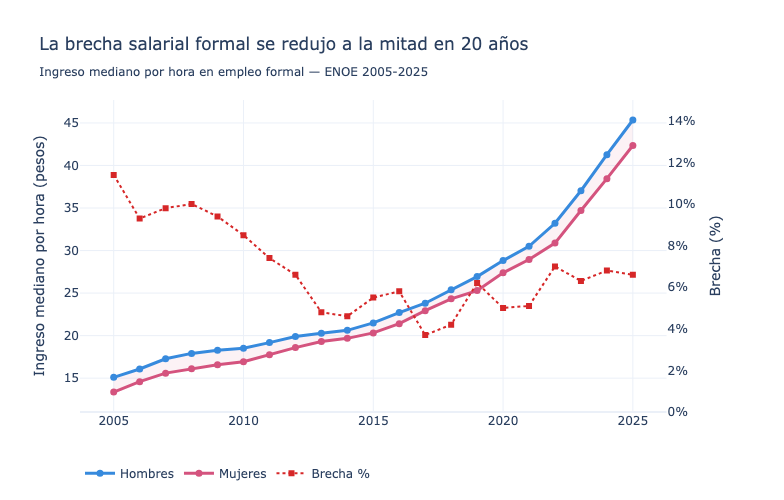

In [2]:
# Calcular serie temporal
serie = []
for anio in sorted(df['anio'].unique()):
    b = brecha_grupo(df[df['anio'] == anio])
    serie.append({'anio': anio, 'Hombre': b['ih'], 'Mujer': b['im'], 'brecha': b['brecha']})
df_serie = pd.DataFrame(serie)

fig = make_subplots(specs=[[{'secondary_y': True}]])

# Área de brecha (fondo)
fig.add_trace(go.Scatter(
    x=list(df_serie['anio']) + list(df_serie['anio'][::-1]),
    y=list(df_serie['Hombre']) + list(df_serie['Mujer'][::-1]),
    fill='toself', fillcolor='rgba(212,83,126,0.08)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip', name='Brecha', showlegend=False
), secondary_y=False)

# Líneas H y M
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Hombre'],
    mode='lines+markers', name='Hombres',
    line=dict(color=COLOR_H, width=3), marker=dict(size=7)
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Mujer'],
    mode='lines+markers', name='Mujeres',
    line=dict(color=COLOR_M, width=3), marker=dict(size=7)
), secondary_y=False)

# Brecha % en eje secundario
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['brecha'],
    mode='lines+markers', name='Brecha %',
    line=dict(color=COLOR_ROJO, width=2, dash='dot'),
    marker=dict(size=6, symbol='square')
), secondary_y=True)

fig.update_layout(
    title='La brecha salarial formal se redujo a la mitad en 20 años<br>'
          '<sub>Ingreso mediano por hora en empleo formal — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    legend=dict(orientation='h', y=-0.15),
    hovermode='x unified'
)
fig.update_yaxes(title_text='Ingreso mediano por hora (pesos)', secondary_y=False)
fig.update_yaxes(title_text='Brecha (%)', secondary_y=True, range=[0, 15],
                 ticksuffix='%', showgrid=False)

#fig.write_html(RUTA_SALIDA / 'g1_serie_temporal.html', include_plotlyjs='cdn')
fig.show()

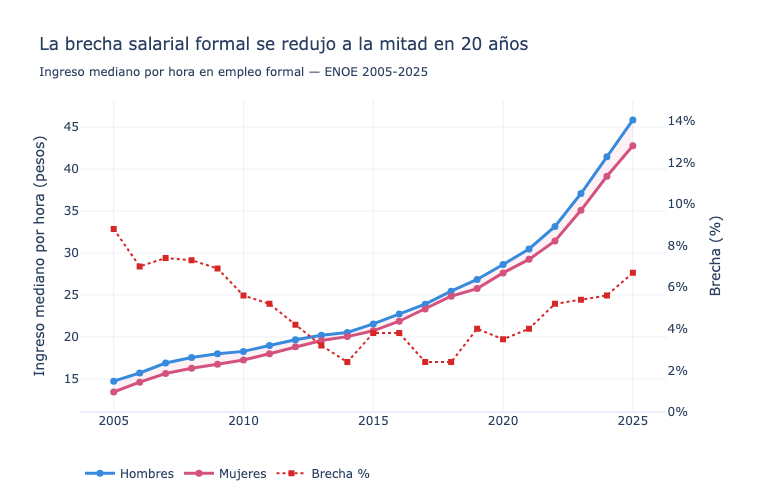

In [19]:
# Calcular serie temporal DF_SI
serie = []
for anio in sorted(df['anio'].unique()):
    b = brecha_grupo(df[df['anio'] == anio])
    serie.append({'anio': anio, 'Hombre': b['ih'], 'Mujer': b['im'], 'brecha': b['brecha']})
df_serie = pd.DataFrame(serie)

fig = make_subplots(specs=[[{'secondary_y': True}]])

# Área de brecha (fondo)
fig.add_trace(go.Scatter(
    x=list(df_serie['anio']) + list(df_serie['anio'][::-1]),
    y=list(df_serie['Hombre']) + list(df_serie['Mujer'][::-1]),
    fill='toself', fillcolor='rgba(212,83,126,0.08)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip', name='Brecha', showlegend=False
), secondary_y=False)

# Líneas H y M
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Hombre'],
    mode='lines+markers', name='Hombres',
    line=dict(color=COLOR_H, width=3), marker=dict(size=7)
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Mujer'],
    mode='lines+markers', name='Mujeres',
    line=dict(color=COLOR_M, width=3), marker=dict(size=7)
), secondary_y=False)

# Brecha % en eje secundario
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['brecha'],
    mode='lines+markers', name='Brecha %',
    line=dict(color=COLOR_ROJO, width=2, dash='dot'),
    marker=dict(size=6, symbol='square')
), secondary_y=True)

fig.update_layout(
    title='La brecha salarial formal se redujo a la mitad en 20 años<br>'
          '<sub>Ingreso mediano por hora en empleo formal — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    legend=dict(orientation='h', y=-0.15),
    hovermode='x unified'
)
fig.update_yaxes(title_text='Ingreso mediano por hora (pesos)', secondary_y=False)
fig.update_yaxes(title_text='Brecha (%)', secondary_y=True, range=[0, 15],
                 ticksuffix='%', showgrid=False)

#fig.write_html(RUTA_SALIDA / 'g1_serie_temporal.html', include_plotlyjs='cdn')
fig.show()

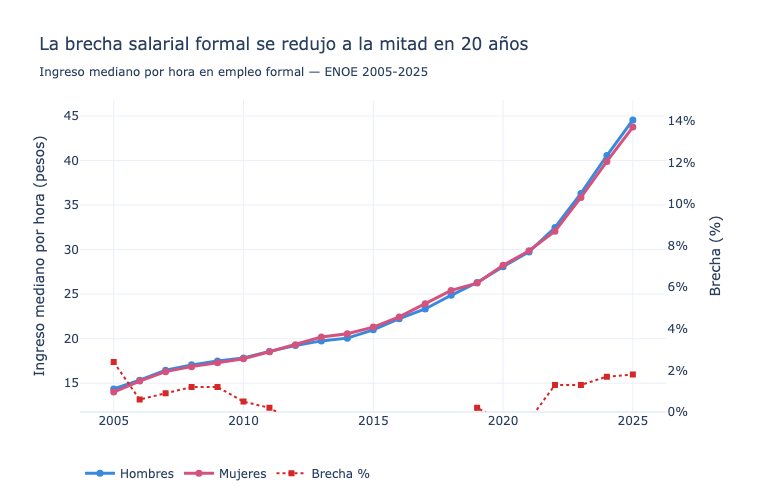

In [32]:
# Calcular serie temporal DF_NO
serie = []
for anio in sorted(df['anio'].unique()):
    b = brecha_grupo(df[df['anio'] == anio])
    serie.append({'anio': anio, 'Hombre': b['ih'], 'Mujer': b['im'], 'brecha': b['brecha']})
df_serie = pd.DataFrame(serie)

fig = make_subplots(specs=[[{'secondary_y': True}]])

# Área de brecha (fondo)
fig.add_trace(go.Scatter(
    x=list(df_serie['anio']) + list(df_serie['anio'][::-1]),
    y=list(df_serie['Hombre']) + list(df_serie['Mujer'][::-1]),
    fill='toself', fillcolor='rgba(212,83,126,0.08)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip', name='Brecha', showlegend=False
), secondary_y=False)

# Líneas H y M
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Hombre'],
    mode='lines+markers', name='Hombres',
    line=dict(color=COLOR_H, width=3), marker=dict(size=7)
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Mujer'],
    mode='lines+markers', name='Mujeres',
    line=dict(color=COLOR_M, width=3), marker=dict(size=7)
), secondary_y=False)

# Brecha % en eje secundario
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['brecha'],
    mode='lines+markers', name='Brecha %',
    line=dict(color=COLOR_ROJO, width=2, dash='dot'),
    marker=dict(size=6, symbol='square')
), secondary_y=True)

fig.update_layout(
    title='La brecha salarial formal se redujo a la mitad en 20 años<br>'
          '<sub>Ingreso mediano por hora en empleo formal — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    legend=dict(orientation='h', y=-0.15),
    hovermode='x unified'
)
fig.update_yaxes(title_text='Ingreso mediano por hora (pesos)', secondary_y=False)
fig.update_yaxes(title_text='Brecha (%)', secondary_y=True, range=[0, 15],
                 ticksuffix='%', showgrid=False)

#fig.write_html(RUTA_SALIDA / 'g1_serie_temporal.html', include_plotlyjs='cdn')
fig.show()

---
## G2 — Brecha salarial por sector (barras divergentes)

**Hallazgo**: en 3 sectores las mujeres ganan MÁS que los hombres. La paradoja del acceso.

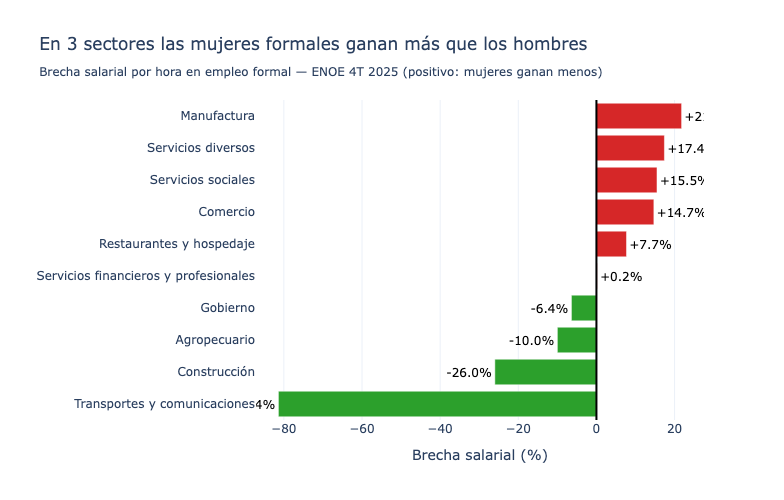

In [4]:
d25 = df[df['anio'] == 2025]

# Brecha y feminización por sector
rows = []
for sec in d25['sector'].unique():
    ds = d25[d25['sector'] == sec]
    b = brecha_grupo(ds)
    pob_m = ds[ds['sexo']=='Mujer']['poblacion_ocupada'].sum()
    pob_t = ds['poblacion_ocupada'].sum()
    rows.append({'sector': sec, **b, 'pct_mujeres': round(pob_m/pob_t*100,1), 'poblacion': pob_t})

df_sec = pd.DataFrame(rows).dropna(subset=['brecha'])
# Filtrar outliers extremos (industria extractiva con muestra pequeña)
df_sec = df_sec[df_sec['brecha'].between(-100, 100)]
df_sec = df_sec.sort_values('brecha', ascending=True)

colores = [COLOR_ROJO if v > 0 else COLOR_VERDE for v in df_sec['brecha']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_sec['sector'], x=df_sec['brecha'],
    orientation='h', marker_color=colores,
    text=[f'{v:+.1f}%' for v in df_sec['brecha']],
    textposition='outside', textfont=dict(size=12, color='black'),
    hovertemplate='<b>%{y}</b><br>Brecha: %{x:.1f}%<br>'
                  'Hombres: $%{customdata[0]:.0f}/hr<br>'
                  'Mujeres: $%{customdata[1]:.0f}/hr<br>'
                  'Mujeres en el sector: %{customdata[2]:.0f}%',
    customdata=df_sec[['ih','im','pct_mujeres']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

fig.update_layout(
    title='En 3 sectores las mujeres formales ganan más que los hombres<br>'
          '<sub>Brecha salarial por hora en empleo formal — ENOE 4T 2025 '
          '(positivo: mujeres ganan menos)</sub>',
    template='plotly_white', height=500,
    xaxis_title='Brecha salarial (%)',
    yaxis_title='',
    margin=dict(l=250)
)

#fig.write_html(RUTA_SALIDA / 'g2_brecha_sector.html', include_plotlyjs='cdn')
fig.show()

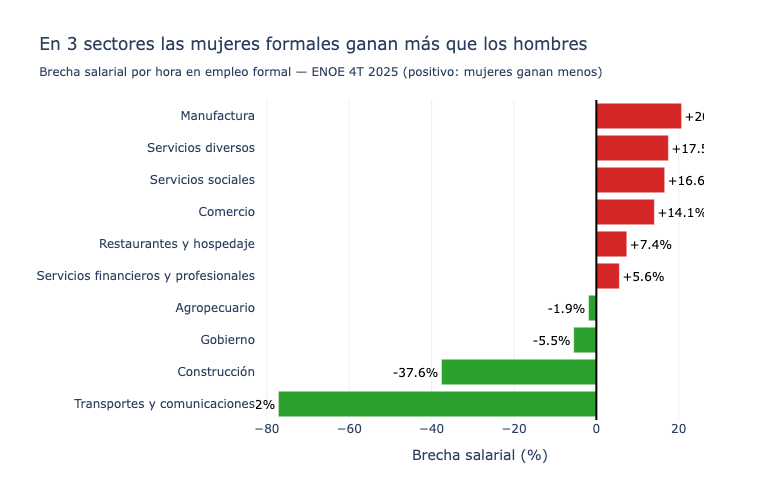

In [21]:
d25 = df[df['anio'] == 2025] #DF_SI

# Brecha y feminización por sector
rows = []
for sec in d25['sector'].unique():
    ds = d25[d25['sector'] == sec]
    b = brecha_grupo(ds)
    pob_m = ds[ds['sexo']=='Mujer']['poblacion_ocupada'].sum()
    pob_t = ds['poblacion_ocupada'].sum()
    rows.append({'sector': sec, **b, 'pct_mujeres': round(pob_m/pob_t*100,1), 'poblacion': pob_t})

df_sec = pd.DataFrame(rows).dropna(subset=['brecha'])
# Filtrar outliers extremos (industria extractiva con muestra pequeña)
df_sec = df_sec[df_sec['brecha'].between(-100, 100)]
df_sec = df_sec.sort_values('brecha', ascending=True)

colores = [COLOR_ROJO if v > 0 else COLOR_VERDE for v in df_sec['brecha']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_sec['sector'], x=df_sec['brecha'],
    orientation='h', marker_color=colores,
    text=[f'{v:+.1f}%' for v in df_sec['brecha']],
    textposition='outside', textfont=dict(size=12, color='black'),
    hovertemplate='<b>%{y}</b><br>Brecha: %{x:.1f}%<br>'
                  'Hombres: $%{customdata[0]:.0f}/hr<br>'
                  'Mujeres: $%{customdata[1]:.0f}/hr<br>'
                  'Mujeres en el sector: %{customdata[2]:.0f}%',
    customdata=df_sec[['ih','im','pct_mujeres']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

fig.update_layout(
    title='En 3 sectores las mujeres formales ganan más que los hombres<br>'
          '<sub>Brecha salarial por hora en empleo formal — ENOE 4T 2025 '
          '(positivo: mujeres ganan menos)</sub>',
    template='plotly_white', height=500,
    xaxis_title='Brecha salarial (%)',
    yaxis_title='',
    margin=dict(l=250)
)

#fig.write_html(RUTA_SALIDA / 'g2_brecha_sector.html', include_plotlyjs='cdn')
fig.show()

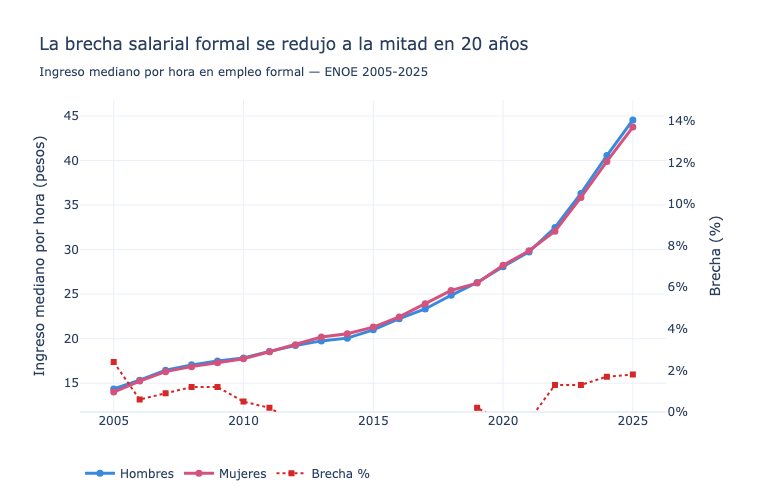

In [33]:
# Calcular serie temporal DF_NO
serie = []
for anio in sorted(df['anio'].unique()):
    b = brecha_grupo(df[df['anio'] == anio])
    serie.append({'anio': anio, 'Hombre': b['ih'], 'Mujer': b['im'], 'brecha': b['brecha']})
df_serie = pd.DataFrame(serie)

fig = make_subplots(specs=[[{'secondary_y': True}]])

# Área de brecha (fondo)
fig.add_trace(go.Scatter(
    x=list(df_serie['anio']) + list(df_serie['anio'][::-1]),
    y=list(df_serie['Hombre']) + list(df_serie['Mujer'][::-1]),
    fill='toself', fillcolor='rgba(212,83,126,0.08)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip', name='Brecha', showlegend=False
), secondary_y=False)

# Líneas H y M
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Hombre'],
    mode='lines+markers', name='Hombres',
    line=dict(color=COLOR_H, width=3), marker=dict(size=7)
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['Mujer'],
    mode='lines+markers', name='Mujeres',
    line=dict(color=COLOR_M, width=3), marker=dict(size=7)
), secondary_y=False)

# Brecha % en eje secundario
fig.add_trace(go.Scatter(
    x=df_serie['anio'], y=df_serie['brecha'],
    mode='lines+markers', name='Brecha %',
    line=dict(color=COLOR_ROJO, width=2, dash='dot'),
    marker=dict(size=6, symbol='square')
), secondary_y=True)

fig.update_layout(
    title='La brecha salarial formal se redujo a la mitad en 20 años<br>'
          '<sub>Ingreso mediano por hora en empleo formal — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    legend=dict(orientation='h', y=-0.15),
    hovermode='x unified'
)
fig.update_yaxes(title_text='Ingreso mediano por hora (pesos)', secondary_y=False)
fig.update_yaxes(title_text='Brecha (%)', secondary_y=True, range=[0, 15],
                 ticksuffix='%', showgrid=False)

#fig.write_html(RUTA_SALIDA / 'g1_serie_temporal.html', include_plotlyjs='cdn')
fig.show()

---
## G3 — Feminización vs brecha (scatter revelador)

**Hallazgo**: los sectores más feminizados NO tienen menor brecha. Los menos feminizados favorecen a mujeres.

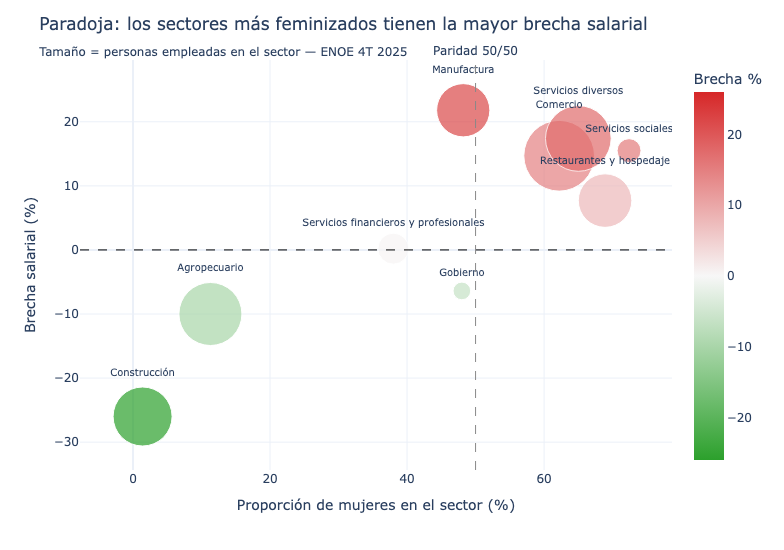

In [5]:
df_plot = df_sec[df_sec['brecha'].between(-50, 30)].copy()  # sin outliers extremos

fig = px.scatter(
    df_plot, x='pct_mujeres', y='brecha',
    size='poblacion', size_max=50,
    color='brecha',
    color_continuous_scale=['#2ca02c', '#f7f7f7', '#d62728'],
    color_continuous_midpoint=0,
    text='sector',
    hover_data={'ih': ':.0f', 'im': ':.0f', 'poblacion': ':,.0f'}
)

fig.update_traces(textposition='top center', textfont_size=10)

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)
fig.add_vline(x=50, line_dash='dash', line_color=COLOR_GRIS, line_width=1,
              annotation_text='Paridad 50/50', annotation_position='top')

fig.update_layout(
    title='Paradoja: los sectores más feminizados tienen la mayor brecha salarial<br>'
          '<sub>Tamaño = personas empleadas en el sector — ENOE 4T 2025</sub>',
    template='plotly_white', height=550,
    xaxis_title='Proporción de mujeres en el sector (%)',
    yaxis_title='Brecha salarial (%)',
    coloraxis_colorbar_title='Brecha %'
)

#fig.write_html(RUTA_SALIDA / 'g3_feminizacion_vs_brecha.html', include_plotlyjs='cdn')
fig.show()

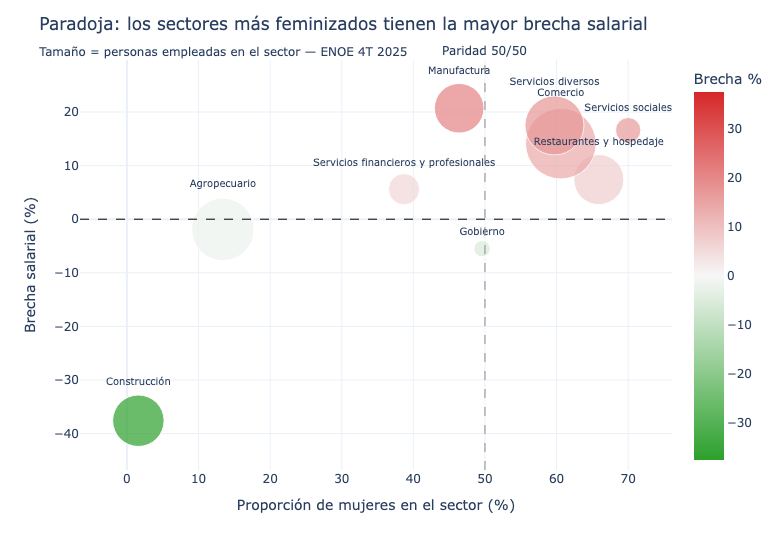

In [22]:
#DF_SI
df_plot = df_sec[df_sec['brecha'].between(-50, 30)].copy()  # sin outliers extremos

fig = px.scatter(
    df_plot, x='pct_mujeres', y='brecha',
    size='poblacion', size_max=50,
    color='brecha',
    color_continuous_scale=['#2ca02c', '#f7f7f7', '#d62728'],
    color_continuous_midpoint=0,
    text='sector',
    hover_data={'ih': ':.0f', 'im': ':.0f', 'poblacion': ':,.0f'}
)

fig.update_traces(textposition='top center', textfont_size=10)

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)
fig.add_vline(x=50, line_dash='dash', line_color=COLOR_GRIS, line_width=1,
              annotation_text='Paridad 50/50', annotation_position='top')

fig.update_layout(
    title='Paradoja: los sectores más feminizados tienen la mayor brecha salarial<br>'
          '<sub>Tamaño = personas empleadas en el sector — ENOE 4T 2025</sub>',
    template='plotly_white', height=550,
    xaxis_title='Proporción de mujeres en el sector (%)',
    yaxis_title='Brecha salarial (%)',
    coloraxis_colorbar_title='Brecha %'
)

#fig.write_html(RUTA_SALIDA / 'g3_feminizacion_vs_brecha.html', include_plotlyjs='cdn')
fig.show()

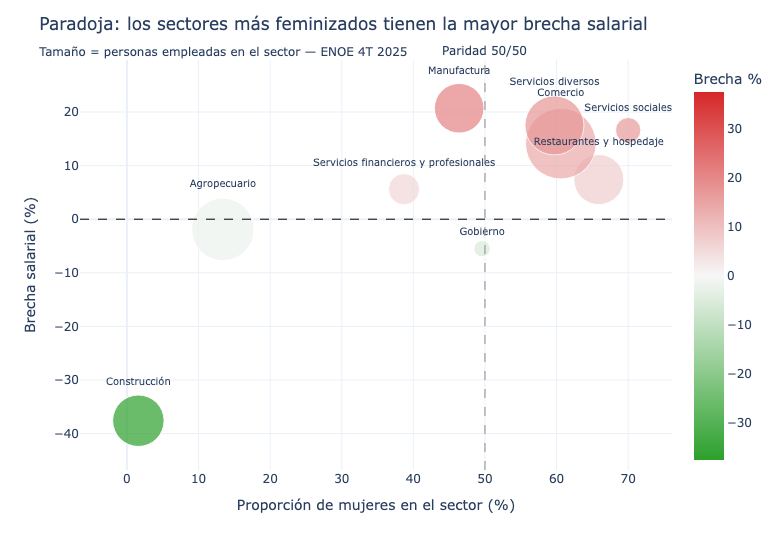

In [34]:
#DF_NO
df_plot = df_sec[df_sec['brecha'].between(-50, 30)].copy()  # sin outliers extremos

fig = px.scatter(
    df_plot, x='pct_mujeres', y='brecha',
    size='poblacion', size_max=50,
    color='brecha',
    color_continuous_scale=['#2ca02c', '#f7f7f7', '#d62728'],
    color_continuous_midpoint=0,
    text='sector',
    hover_data={'ih': ':.0f', 'im': ':.0f', 'poblacion': ':,.0f'}
)

fig.update_traces(textposition='top center', textfont_size=10)

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)
fig.add_vline(x=50, line_dash='dash', line_color=COLOR_GRIS, line_width=1,
              annotation_text='Paridad 50/50', annotation_position='top')

fig.update_layout(
    title='Paradoja: los sectores más feminizados tienen la mayor brecha salarial<br>'
          '<sub>Tamaño = personas empleadas en el sector — ENOE 4T 2025</sub>',
    template='plotly_white', height=550,
    xaxis_title='Proporción de mujeres en el sector (%)',
    yaxis_title='Brecha salarial (%)',
    coloraxis_colorbar_title='Brecha %'
)

#fig.write_html(RUTA_SALIDA / 'g3_feminizacion_vs_brecha.html', include_plotlyjs='cdn')
fig.show()

---
## G4 — Evolución de la brecha por sector 2005-2025

**Hallazgo**: Manufactura mejoró 10pp pero sigue siendo la peor. Gobierno siempre favoreció a mujeres.

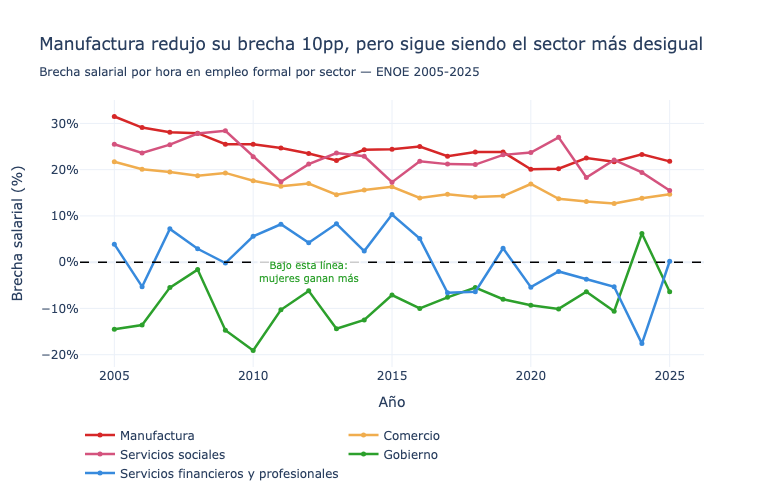

In [6]:
sectores_foco = ['Manufactura', 'Comercio', 'Servicios sociales',
                 'Gobierno', 'Servicios financieros y profesionales']
colores_sec = [COLOR_ROJO, COLOR_AMARILLO, COLOR_M, COLOR_VERDE, COLOR_H]

fig = go.Figure()
for sec, color in zip(sectores_foco, colores_sec):
    brechas = []
    for anio in sorted(df['anio'].unique()):
        b = brecha_grupo(df[(df['anio']==anio) & (df['sector']==sec)])
        brechas.append({'anio': anio, 'brecha': b['brecha']})
    ds = pd.DataFrame(brechas).dropna()
    fig.add_trace(go.Scatter(
        x=ds['anio'], y=ds['brecha'],
        mode='lines+markers', name=sec,
        line=dict(color=color, width=2.5), marker=dict(size=5)
    ))

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1.5)
fig.add_annotation(
    x=2012, y=-2, text='Bajo esta línea:<br>mujeres ganan más',
    showarrow=False, font=dict(size=10, color=COLOR_VERDE),
    bgcolor='rgba(255,255,255,0.8)'
)

fig.update_layout(
    title='Manufactura redujo su brecha 10pp, pero sigue siendo el sector más desigual<br>'
          '<sub>Brecha salarial por hora en empleo formal por sector — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    xaxis_title='Año', yaxis_title='Brecha salarial (%)',
    yaxis_ticksuffix='%',
    legend=dict(orientation='h', y=-0.2),
    hovermode='x unified'
)

#fig.write_html(RUTA_SALIDA / 'g4_brecha_sector_temporal.html', include_plotlyjs='cdn')
fig.show()

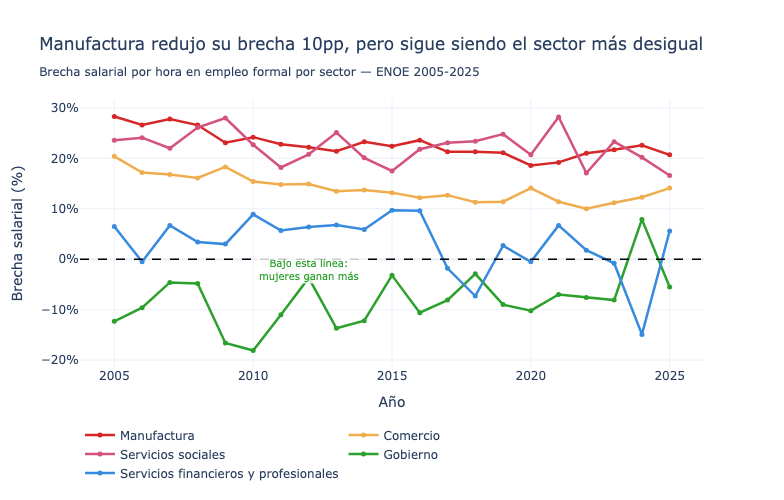

In [23]:
#DF_SI
sectores_foco = ['Manufactura', 'Comercio', 'Servicios sociales',
                 'Gobierno', 'Servicios financieros y profesionales']
colores_sec = [COLOR_ROJO, COLOR_AMARILLO, COLOR_M, COLOR_VERDE, COLOR_H]

fig = go.Figure()
for sec, color in zip(sectores_foco, colores_sec):
    brechas = []
    for anio in sorted(df['anio'].unique()):
        b = brecha_grupo(df[(df['anio']==anio) & (df['sector']==sec)])
        brechas.append({'anio': anio, 'brecha': b['brecha']})
    ds = pd.DataFrame(brechas).dropna()
    fig.add_trace(go.Scatter(
        x=ds['anio'], y=ds['brecha'],
        mode='lines+markers', name=sec,
        line=dict(color=color, width=2.5), marker=dict(size=5)
    ))

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1.5)
fig.add_annotation(
    x=2012, y=-2, text='Bajo esta línea:<br>mujeres ganan más',
    showarrow=False, font=dict(size=10, color=COLOR_VERDE),
    bgcolor='rgba(255,255,255,0.8)'
)

fig.update_layout(
    title='Manufactura redujo su brecha 10pp, pero sigue siendo el sector más desigual<br>'
          '<sub>Brecha salarial por hora en empleo formal por sector — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    xaxis_title='Año', yaxis_title='Brecha salarial (%)',
    yaxis_ticksuffix='%',
    legend=dict(orientation='h', y=-0.2),
    hovermode='x unified'
)

#fig.write_html(RUTA_SALIDA / 'g4_brecha_sector_temporal.html', include_plotlyjs='cdn')
fig.show()

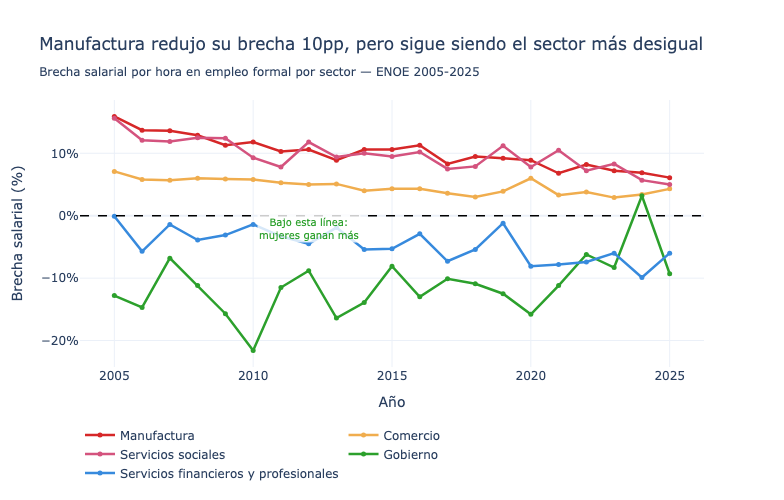

In [35]:
#DF_NO
sectores_foco = ['Manufactura', 'Comercio', 'Servicios sociales',
                 'Gobierno', 'Servicios financieros y profesionales']
colores_sec = [COLOR_ROJO, COLOR_AMARILLO, COLOR_M, COLOR_VERDE, COLOR_H]

fig = go.Figure()
for sec, color in zip(sectores_foco, colores_sec):
    brechas = []
    for anio in sorted(df['anio'].unique()):
        b = brecha_grupo(df[(df['anio']==anio) & (df['sector']==sec)])
        brechas.append({'anio': anio, 'brecha': b['brecha']})
    ds = pd.DataFrame(brechas).dropna()
    fig.add_trace(go.Scatter(
        x=ds['anio'], y=ds['brecha'],
        mode='lines+markers', name=sec,
        line=dict(color=color, width=2.5), marker=dict(size=5)
    ))

fig.add_hline(y=0, line_dash='dash', line_color='black', line_width=1.5)
fig.add_annotation(
    x=2012, y=-2, text='Bajo esta línea:<br>mujeres ganan más',
    showarrow=False, font=dict(size=10, color=COLOR_VERDE),
    bgcolor='rgba(255,255,255,0.8)'
)

fig.update_layout(
    title='Manufactura redujo su brecha 10pp, pero sigue siendo el sector más desigual<br>'
          '<sub>Brecha salarial por hora en empleo formal por sector — ENOE 2005-2025</sub>',
    template='plotly_white', height=500,
    xaxis_title='Año', yaxis_title='Brecha salarial (%)',
    yaxis_ticksuffix='%',
    legend=dict(orientation='h', y=-0.2),
    hovermode='x unified'
)

#fig.write_html(RUTA_SALIDA / 'g4_brecha_sector_temporal.html', include_plotlyjs='cdn')
fig.show()

---
## G5 — Brecha por nivel educativo

**Hallazgo**: la educación reduce la brecha de 12.3% a 5.7%, pero no la elimina.

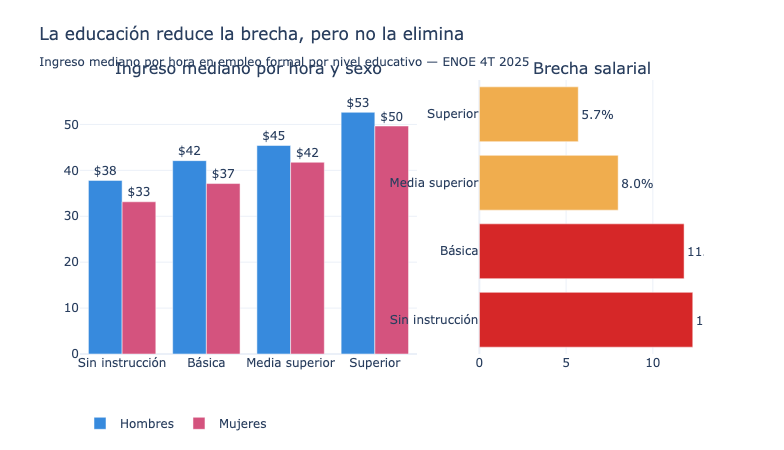

In [7]:
# Calcular brecha e ingresos por nivel educativo
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
rows_edu = []
for edu in orden_edu:
    de = d25[d25['nivel_educ'] == edu]
    b = brecha_grupo(de)
    rows_edu.append({'nivel_educ': edu, **b})
df_edu = pd.DataFrame(rows_edu)

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.6, 0.4],
    subplot_titles=['Ingreso mediano por hora y sexo', 'Brecha salarial']
)

# Barras agrupadas H vs M
fig.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['ih'],
    name='Hombres', marker_color=COLOR_H,
    text=[f'${v:.0f}' for v in df_edu['ih']], textposition='outside'
), row=1, col=1)
fig.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['im'],
    name='Mujeres', marker_color=COLOR_M,
    text=[f'${v:.0f}' for v in df_edu['im']], textposition='outside'
), row=1, col=1)

# Barras horizontales de brecha
colores_b = [COLOR_ROJO if v > 8 else COLOR_AMARILLO if v > 5 else COLOR_VERDE
             for v in df_edu['brecha']]
fig.add_trace(go.Bar(
    y=df_edu['nivel_educ'], x=df_edu['brecha'],
    orientation='h', marker_color=colores_b, showlegend=False,
    text=[f'{v:.1f}%' for v in df_edu['brecha']], textposition='outside'
), row=1, col=2)

fig.update_layout(
    title='La educación reduce la brecha, pero no la elimina<br>'
          '<sub>Ingreso mediano por hora en empleo formal por nivel educativo — ENOE 4T 2025</sub>',
    template='plotly_white', height=450,
    barmode='group', legend=dict(orientation='h', y=-0.2),
    margin=dict(t=80)
)

#fig.write_html(RUTA_SALIDA / 'g5_brecha_educacion.html', include_plotlyjs='cdn')
fig.show()

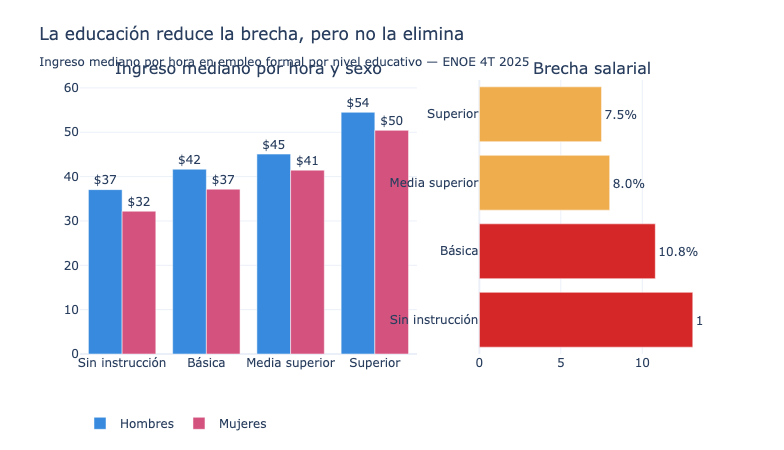

In [24]:
#DF_SI
# Calcular brecha e ingresos por nivel educativo
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
rows_edu = []
for edu in orden_edu:
    de = d25[d25['nivel_educ'] == edu]
    b = brecha_grupo(de)
    rows_edu.append({'nivel_educ': edu, **b})
df_edu = pd.DataFrame(rows_edu)

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.6, 0.4],
    subplot_titles=['Ingreso mediano por hora y sexo', 'Brecha salarial']
)

# Barras agrupadas H vs M
fig.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['ih'],
    name='Hombres', marker_color=COLOR_H,
    text=[f'${v:.0f}' for v in df_edu['ih']], textposition='outside'
), row=1, col=1)
fig.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['im'],
    name='Mujeres', marker_color=COLOR_M,
    text=[f'${v:.0f}' for v in df_edu['im']], textposition='outside'
), row=1, col=1)

# Barras horizontales de brecha
colores_b = [COLOR_ROJO if v > 8 else COLOR_AMARILLO if v > 5 else COLOR_VERDE
             for v in df_edu['brecha']]
fig.add_trace(go.Bar(
    y=df_edu['nivel_educ'], x=df_edu['brecha'],
    orientation='h', marker_color=colores_b, showlegend=False,
    text=[f'{v:.1f}%' for v in df_edu['brecha']], textposition='outside'
), row=1, col=2)

fig.update_layout(
    title='La educación reduce la brecha, pero no la elimina<br>'
          '<sub>Ingreso mediano por hora en empleo formal por nivel educativo — ENOE 4T 2025</sub>',
    template='plotly_white', height=450,
    barmode='group', legend=dict(orientation='h', y=-0.2),
    margin=dict(t=80)
)

#fig.write_html(RUTA_SALIDA / 'g5_brecha_educacion.html', include_plotlyjs='cdn')
fig.show()

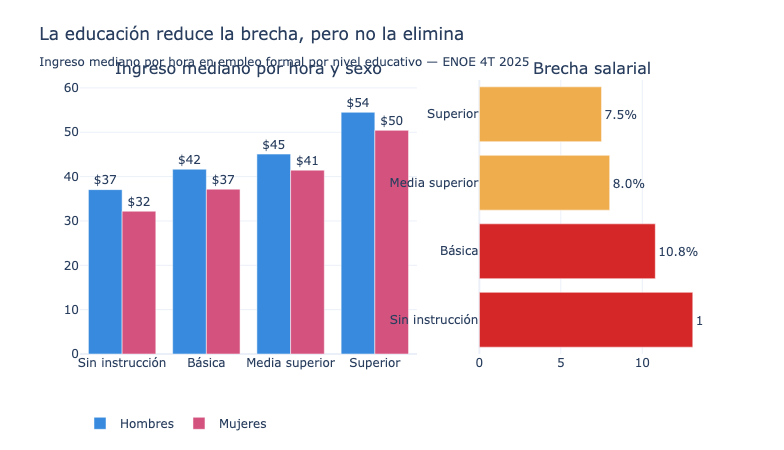

In [36]:
#DF_NO
# Calcular brecha e ingresos por nivel educativo
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
rows_edu = []
for edu in orden_edu:
    de = d25[d25['nivel_educ'] == edu]
    b = brecha_grupo(de)
    rows_edu.append({'nivel_educ': edu, **b})
df_edu = pd.DataFrame(rows_edu)

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.6, 0.4],
    subplot_titles=['Ingreso mediano por hora y sexo', 'Brecha salarial']
)

# Barras agrupadas H vs M
fig.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['ih'],
    name='Hombres', marker_color=COLOR_H,
    text=[f'${v:.0f}' for v in df_edu['ih']], textposition='outside'
), row=1, col=1)
fig.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['im'],
    name='Mujeres', marker_color=COLOR_M,
    text=[f'${v:.0f}' for v in df_edu['im']], textposition='outside'
), row=1, col=1)

# Barras horizontales de brecha
colores_b = [COLOR_ROJO if v > 8 else COLOR_AMARILLO if v > 5 else COLOR_VERDE
             for v in df_edu['brecha']]
fig.add_trace(go.Bar(
    y=df_edu['nivel_educ'], x=df_edu['brecha'],
    orientation='h', marker_color=colores_b, showlegend=False,
    text=[f'{v:.1f}%' for v in df_edu['brecha']], textposition='outside'
), row=1, col=2)

fig.update_layout(
    title='La educación reduce la brecha, pero no la elimina<br>'
          '<sub>Ingreso mediano por hora en empleo formal por nivel educativo — ENOE 4T 2025</sub>',
    template='plotly_white', height=450,
    barmode='group', legend=dict(orientation='h', y=-0.2),
    margin=dict(t=80)
)

#fig.write_html(RUTA_SALIDA / 'g5_brecha_educacion.html', include_plotlyjs='cdn')
fig.show()

---
## G6 — Cambio de brecha por ocupación 2005 vs 2025

**Hallazgo**: Directivos EMPEORARON (+4.5pp). Administrativos y profesionistas mejoraron ~10pp.

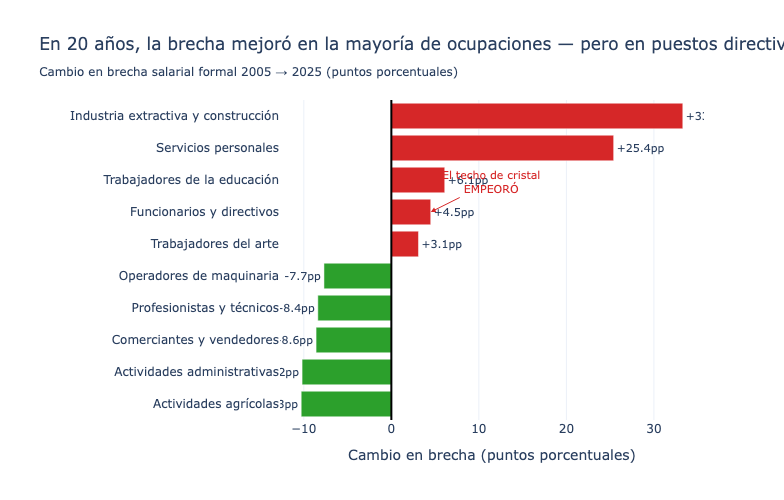

In [8]:
# Calcular brecha 2005 y 2025 por ocupación
rows_cambio = []
for ocu in df['ocupacion'].unique():
    b05 = brecha_grupo(df[(df['anio']==2005) & (df['ocupacion']==ocu)])
    b25 = brecha_grupo(df[(df['anio']==2025) & (df['ocupacion']==ocu)])
    if pd.isna(b05['brecha']) or pd.isna(b25['brecha']): continue
    rows_cambio.append({
        'ocupacion': ocu, 'brecha_2005': b05['brecha'],
        'brecha_2025': b25['brecha'], 'cambio': round(b25['brecha'] - b05['brecha'], 1)
    })

df_cambio = pd.DataFrame(rows_cambio).sort_values('cambio')

colores_cambio = [COLOR_VERDE if v < 0 else COLOR_ROJO for v in df_cambio['cambio']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_cambio['ocupacion'], x=df_cambio['cambio'],
    orientation='h', marker_color=colores_cambio,
    text=[f'{v:+.1f}pp' for v in df_cambio['cambio']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha 2005: %{customdata[0]:+.1f}%<br>'
                  'Brecha 2025: %{customdata[1]:+.1f}%<br>'
                  'Cambio: %{customdata[2]:+.1f}pp',
    customdata=df_cambio[['brecha_2005','brecha_2025','cambio']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

# Anotación sobre directivos
fig.add_annotation(
    x=df_cambio[df_cambio['ocupacion']=='Funcionarios y directivos']['cambio'].iloc[0],
    y='Funcionarios y directivos',
    text='El techo de cristal<br>EMPEORÓ',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ROJO,
    font=dict(size=11, color=COLOR_ROJO),
    ax=60, ay=-30
)

fig.update_layout(
    title='En 20 años, la brecha mejoró en la mayoría de ocupaciones — pero en puestos directivos EMPEORÓ<br>'
          '<sub>Cambio en brecha salarial formal 2005 → 2025 (puntos porcentuales)</sub>',
    template='plotly_white', height=500,
    xaxis_title='Cambio en brecha (puntos porcentuales)',
    margin=dict(l=280)
)

#fig.write_html(RUTA_SALIDA / 'g6_cambio_ocupacion.html', include_plotlyjs='cdn')
fig.show()

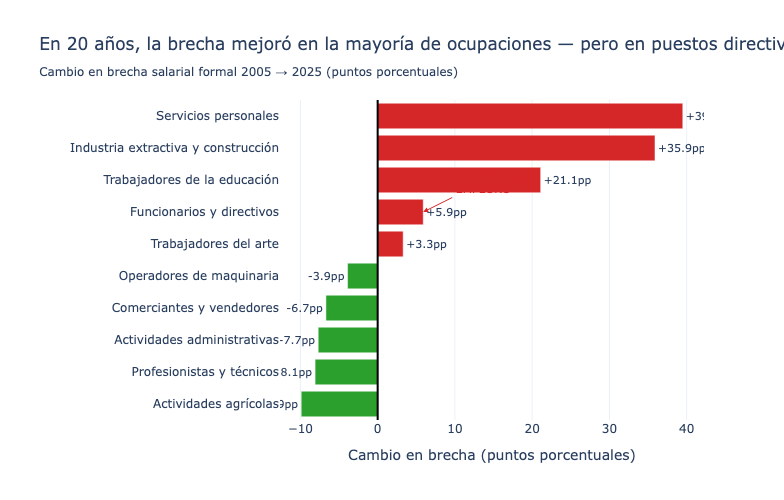

In [25]:
#DF_SI
# Calcular brecha 2005 y 2025 por ocupación
rows_cambio = []
for ocu in df['ocupacion'].unique():
    b05 = brecha_grupo(df[(df['anio']==2005) & (df['ocupacion']==ocu)])
    b25 = brecha_grupo(df[(df['anio']==2025) & (df['ocupacion']==ocu)])
    if pd.isna(b05['brecha']) or pd.isna(b25['brecha']): continue
    rows_cambio.append({
        'ocupacion': ocu, 'brecha_2005': b05['brecha'],
        'brecha_2025': b25['brecha'], 'cambio': round(b25['brecha'] - b05['brecha'], 1)
    })

df_cambio = pd.DataFrame(rows_cambio).sort_values('cambio')

colores_cambio = [COLOR_VERDE if v < 0 else COLOR_ROJO for v in df_cambio['cambio']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_cambio['ocupacion'], x=df_cambio['cambio'],
    orientation='h', marker_color=colores_cambio,
    text=[f'{v:+.1f}pp' for v in df_cambio['cambio']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha 2005: %{customdata[0]:+.1f}%<br>'
                  'Brecha 2025: %{customdata[1]:+.1f}%<br>'
                  'Cambio: %{customdata[2]:+.1f}pp',
    customdata=df_cambio[['brecha_2005','brecha_2025','cambio']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

# Anotación sobre directivos
fig.add_annotation(
    x=df_cambio[df_cambio['ocupacion']=='Funcionarios y directivos']['cambio'].iloc[0],
    y='Funcionarios y directivos',
    text='El techo de cristal<br>EMPEORÓ',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ROJO,
    font=dict(size=11, color=COLOR_ROJO),
    ax=60, ay=-30
)

fig.update_layout(
    title='En 20 años, la brecha mejoró en la mayoría de ocupaciones — pero en puestos directivos EMPEORÓ<br>'
          '<sub>Cambio en brecha salarial formal 2005 → 2025 (puntos porcentuales)</sub>',
    template='plotly_white', height=500,
    xaxis_title='Cambio en brecha (puntos porcentuales)',
    margin=dict(l=280)
)

#fig.write_html(RUTA_SALIDA / 'g6_cambio_ocupacion.html', include_plotlyjs='cdn')
fig.show()

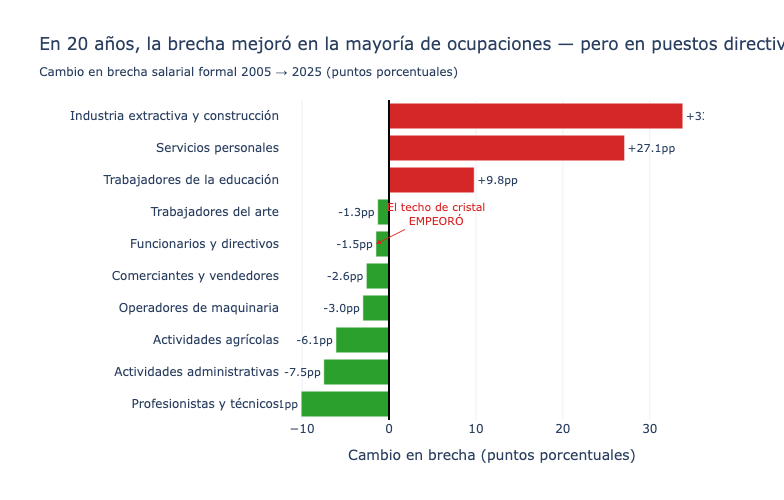

In [37]:
#df_NO
# Calcular brecha 2005 y 2025 por ocupación
rows_cambio = []
for ocu in df['ocupacion'].unique():
    b05 = brecha_grupo(df[(df['anio']==2005) & (df['ocupacion']==ocu)])
    b25 = brecha_grupo(df[(df['anio']==2025) & (df['ocupacion']==ocu)])
    if pd.isna(b05['brecha']) or pd.isna(b25['brecha']): continue
    rows_cambio.append({
        'ocupacion': ocu, 'brecha_2005': b05['brecha'],
        'brecha_2025': b25['brecha'], 'cambio': round(b25['brecha'] - b05['brecha'], 1)
    })

df_cambio = pd.DataFrame(rows_cambio).sort_values('cambio')

colores_cambio = [COLOR_VERDE if v < 0 else COLOR_ROJO for v in df_cambio['cambio']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_cambio['ocupacion'], x=df_cambio['cambio'],
    orientation='h', marker_color=colores_cambio,
    text=[f'{v:+.1f}pp' for v in df_cambio['cambio']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha 2005: %{customdata[0]:+.1f}%<br>'
                  'Brecha 2025: %{customdata[1]:+.1f}%<br>'
                  'Cambio: %{customdata[2]:+.1f}pp',
    customdata=df_cambio[['brecha_2005','brecha_2025','cambio']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

# Anotación sobre directivos
fig.add_annotation(
    x=df_cambio[df_cambio['ocupacion']=='Funcionarios y directivos']['cambio'].iloc[0],
    y='Funcionarios y directivos',
    text='El techo de cristal<br>EMPEORÓ',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ROJO,
    font=dict(size=11, color=COLOR_ROJO),
    ax=60, ay=-30
)

fig.update_layout(
    title='En 20 años, la brecha mejoró en la mayoría de ocupaciones — pero en puestos directivos EMPEORÓ<br>'
          '<sub>Cambio en brecha salarial formal 2005 → 2025 (puntos porcentuales)</sub>',
    template='plotly_white', height=500,
    xaxis_title='Cambio en brecha (puntos porcentuales)',
    margin=dict(l=280)
)

#fig.write_html(RUTA_SALIDA / 'g6_cambio_ocupacion.html', include_plotlyjs='cdn')
fig.show()

---
## G7 — Distribución de la brecha estructural

**Hallazgo**: en 58% de las combinaciones estado×sector×ocupación×educación, los hombres ganan más.

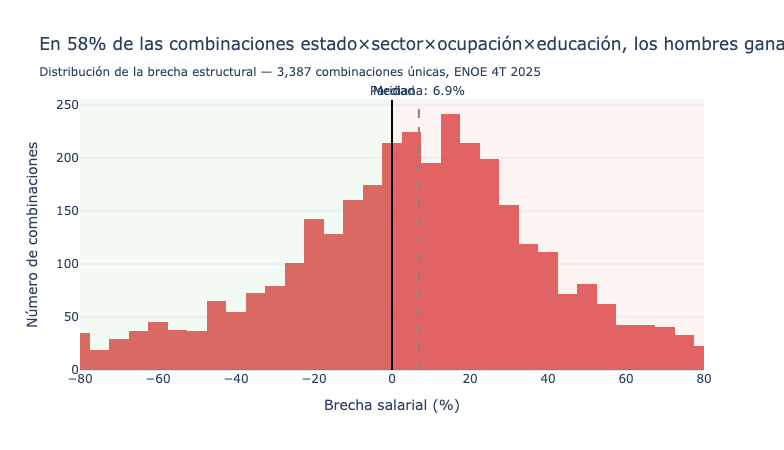

In [9]:
# Pivotar para tener H vs M en la misma fila
pivot_est = d25.pivot_table(
    index=['entidad','sector','ocupacion','nivel_educ'],
    columns='sexo', values='mediana_ing_hora'
).reset_index()
pivot_est.columns.name = None
pivot_est = pivot_est.dropna(subset=['Hombre','Mujer'])
pivot_est['brecha_pct'] = ((pivot_est['Hombre'] - pivot_est['Mujer']) / pivot_est['Hombre'] * 100).round(1)
pivot_est = pivot_est[pivot_est['brecha_pct'].between(-100, 100)]

pct_hm = (pivot_est['brecha_pct'] > 0).mean() * 100
mediana_est = pivot_est['brecha_pct'].median()

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=pivot_est['brecha_pct'], nbinsx=60,
    marker_color=COLOR_ROJO, opacity=0.7,
    name='Combinaciones'
))

fig.add_vline(x=0, line_width=2, line_color='black',
              annotation_text='Paridad', annotation_position='top')
fig.add_vline(x=mediana_est, line_width=2, line_dash='dash', line_color=COLOR_GRIS,
              annotation_text=f'Mediana: {mediana_est:.1f}%', annotation_position='top')

# Sombreado
fig.add_vrect(x0=-100, x1=0, fillcolor=COLOR_VERDE, opacity=0.05,
              annotation_text='Mujeres ganan más', annotation_position='bottom left')
fig.add_vrect(x0=0, x1=100, fillcolor=COLOR_ROJO, opacity=0.05,
              annotation_text='Hombres ganan más', annotation_position='bottom right')

fig.update_layout(
    title=f'En {pct_hm:.0f}% de las combinaciones estado×sector×ocupación×educación, '
          f'los hombres ganan más<br>'
          f'<sub>Distribución de la brecha estructural — {len(pivot_est):,} combinaciones únicas, ENOE 4T 2025</sub>',
    template='plotly_white', height=450,
    xaxis_title='Brecha salarial (%)', xaxis_range=[-80, 80],
    yaxis_title='Número de combinaciones',
    showlegend=False
)

#fig.write_html(RUTA_SALIDA / 'g7_brecha_estructural.html', include_plotlyjs='cdn')
fig.show()

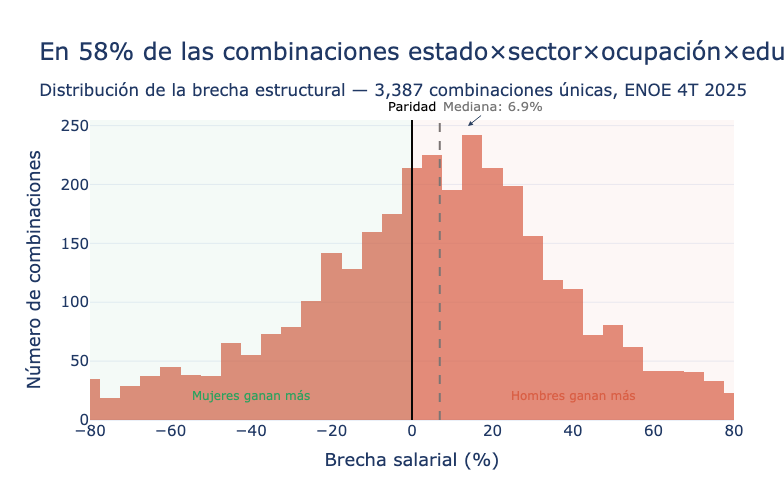

In [13]:
COLOR_OSCURO = '#203864'
COLOR_GRIS = '#777777'
COLOR_ROJO = '#D95F45'
COLOR_VERDE = '#2CA25F'

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=pivot_est['brecha_pct'], 
    nbinsx=60,
    marker_color=COLOR_ROJO, 
    opacity=0.7,
    name='Combinaciones'
))

# Líneas verticales sin texto automático para evitar que se encimen
fig.add_vline(
    x=0, 
    line_width=2, 
    line_color='black'
)

fig.add_vline(
    x=mediana_est, 
    line_width=2, 
    line_dash='dash', 
    line_color=COLOR_GRIS
)

# Sombreado
fig.add_vrect(
    x0=-100, x1=0, 
    fillcolor=COLOR_VERDE, 
    opacity=0.05,
    line_width=0
)

fig.add_vrect(
    x0=0, x1=100, 
    fillcolor=COLOR_ROJO, 
    opacity=0.05,
    line_width=0
)

# Anotaciones separadas
fig.add_annotation(
    x=0,
    y=1.08,
    xref='x',
    yref='paper',
    text='Paridad',
    showarrow=False,
    font=dict(size=13, color='black')
)

fig.add_annotation(
    x=mediana_est + 7,
    y=0.98,
    xref='x',
    yref='paper',
    text=f'Mediana: {mediana_est:.1f}%',
    showarrow=True,
    arrowhead=2,
    ax=25,
    ay=-20,
    font=dict(size=13, color=COLOR_GRIS)
)

# Etiquetas de zonas
fig.add_annotation(
    x=-40,
    y=0.05,
    xref='x',
    yref='paper',
    text='Mujeres ganan más',
    showarrow=False,
    font=dict(size=12, color=COLOR_VERDE)
)

fig.add_annotation(
    x=40,
    y=0.05,
    xref='x',
    yref='paper',
    text='Hombres ganan más',
    showarrow=False,
    font=dict(size=12, color=COLOR_ROJO)
)

fig.update_layout(
    title=(
        f'En {pct_hm:.0f}% de las combinaciones estado×sector×ocupación×educación, '
        f'los hombres ganan más<br>'
        f'<sub>Distribución de la brecha estructural — '
        f'{len(pivot_est):,} combinaciones únicas, ENOE 4T 2025</sub>'
    ),
    template='plotly_white',
    height=500,
    margin=dict(l=90, r=50, t=120, b=80),
    xaxis_title='Brecha salarial (%)',
    xaxis_range=[-80, 80],
    yaxis_title='Número de combinaciones',
    showlegend=False,
    font=dict(size=15, color=COLOR_OSCURO),
    title_font=dict(size=24, color=COLOR_OSCURO)
)

fig.show()

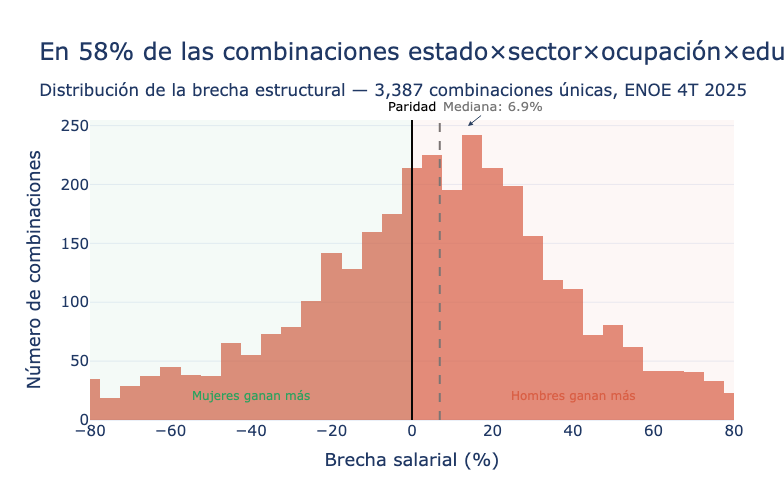

In [26]:
#df_Si
COLOR_OSCURO = '#203864'
COLOR_GRIS = '#777777'
COLOR_ROJO = '#D95F45'
COLOR_VERDE = '#2CA25F'

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=pivot_est['brecha_pct'], 
    nbinsx=60,
    marker_color=COLOR_ROJO, 
    opacity=0.7,
    name='Combinaciones'
))

# Líneas verticales sin texto automático para evitar que se encimen
fig.add_vline(
    x=0, 
    line_width=2, 
    line_color='black'
)

fig.add_vline(
    x=mediana_est, 
    line_width=2, 
    line_dash='dash', 
    line_color=COLOR_GRIS
)

# Sombreado
fig.add_vrect(
    x0=-100, x1=0, 
    fillcolor=COLOR_VERDE, 
    opacity=0.05,
    line_width=0
)

fig.add_vrect(
    x0=0, x1=100, 
    fillcolor=COLOR_ROJO, 
    opacity=0.05,
    line_width=0
)

# Anotaciones separadas
fig.add_annotation(
    x=0,
    y=1.08,
    xref='x',
    yref='paper',
    text='Paridad',
    showarrow=False,
    font=dict(size=13, color='black')
)

fig.add_annotation(
    x=mediana_est + 7,
    y=0.98,
    xref='x',
    yref='paper',
    text=f'Mediana: {mediana_est:.1f}%',
    showarrow=True,
    arrowhead=2,
    ax=25,
    ay=-20,
    font=dict(size=13, color=COLOR_GRIS)
)

# Etiquetas de zonas
fig.add_annotation(
    x=-40,
    y=0.05,
    xref='x',
    yref='paper',
    text='Mujeres ganan más',
    showarrow=False,
    font=dict(size=12, color=COLOR_VERDE)
)

fig.add_annotation(
    x=40,
    y=0.05,
    xref='x',
    yref='paper',
    text='Hombres ganan más',
    showarrow=False,
    font=dict(size=12, color=COLOR_ROJO)
)

fig.update_layout(
    title=(
        f'En {pct_hm:.0f}% de las combinaciones estado×sector×ocupación×educación, '
        f'los hombres ganan más<br>'
        f'<sub>Distribución de la brecha estructural — '
        f'{len(pivot_est):,} combinaciones únicas, ENOE 4T 2025</sub>'
    ),
    template='plotly_white',
    height=500,
    margin=dict(l=90, r=50, t=120, b=80),
    xaxis_title='Brecha salarial (%)',
    xaxis_range=[-80, 80],
    yaxis_title='Número de combinaciones',
    showlegend=False,
    font=dict(size=15, color=COLOR_OSCURO),
    title_font=dict(size=24, color=COLOR_OSCURO)
)

fig.show()

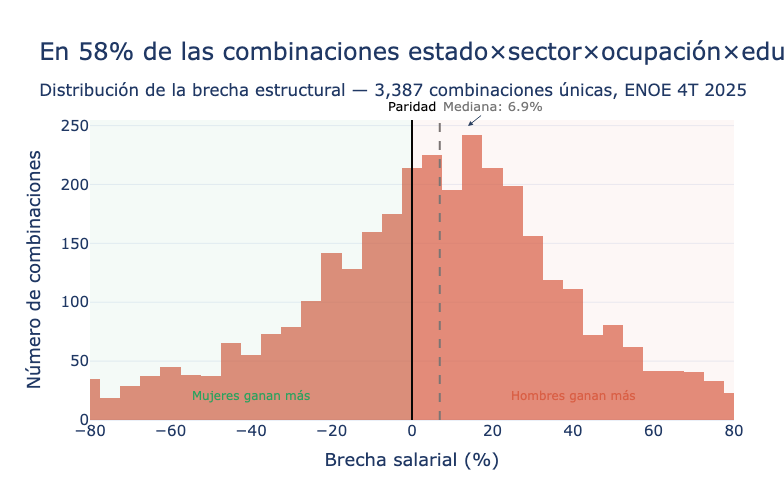

In [38]:
#df_NO
COLOR_OSCURO = '#203864'
COLOR_GRIS = '#777777'
COLOR_ROJO = '#D95F45'
COLOR_VERDE = '#2CA25F'

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=pivot_est['brecha_pct'], 
    nbinsx=60,
    marker_color=COLOR_ROJO, 
    opacity=0.7,
    name='Combinaciones'
))

# Líneas verticales sin texto automático para evitar que se encimen
fig.add_vline(
    x=0, 
    line_width=2, 
    line_color='black'
)

fig.add_vline(
    x=mediana_est, 
    line_width=2, 
    line_dash='dash', 
    line_color=COLOR_GRIS
)

# Sombreado
fig.add_vrect(
    x0=-100, x1=0, 
    fillcolor=COLOR_VERDE, 
    opacity=0.05,
    line_width=0
)

fig.add_vrect(
    x0=0, x1=100, 
    fillcolor=COLOR_ROJO, 
    opacity=0.05,
    line_width=0
)

# Anotaciones separadas
fig.add_annotation(
    x=0,
    y=1.08,
    xref='x',
    yref='paper',
    text='Paridad',
    showarrow=False,
    font=dict(size=13, color='black')
)

fig.add_annotation(
    x=mediana_est + 7,
    y=0.98,
    xref='x',
    yref='paper',
    text=f'Mediana: {mediana_est:.1f}%',
    showarrow=True,
    arrowhead=2,
    ax=25,
    ay=-20,
    font=dict(size=13, color=COLOR_GRIS)
)

# Etiquetas de zonas
fig.add_annotation(
    x=-40,
    y=0.05,
    xref='x',
    yref='paper',
    text='Mujeres ganan más',
    showarrow=False,
    font=dict(size=12, color=COLOR_VERDE)
)

fig.add_annotation(
    x=40,
    y=0.05,
    xref='x',
    yref='paper',
    text='Hombres ganan más',
    showarrow=False,
    font=dict(size=12, color=COLOR_ROJO)
)

fig.update_layout(
    title=(
        f'En {pct_hm:.0f}% de las combinaciones estado×sector×ocupación×educación, '
        f'los hombres ganan más<br>'
        f'<sub>Distribución de la brecha estructural — '
        f'{len(pivot_est):,} combinaciones únicas, ENOE 4T 2025</sub>'
    ),
    template='plotly_white',
    height=500,
    margin=dict(l=90, r=50, t=120, b=80),
    xaxis_title='Brecha salarial (%)',
    xaxis_range=[-80, 80],
    yaxis_title='Número de combinaciones',
    showlegend=False,
    font=dict(size=15, color=COLOR_OSCURO),
    title_font=dict(size=24, color=COLOR_OSCURO)
)

fig.show()

---
## G8 — Mapa de brecha por entidad federativa

**Hallazgo**: Oaxaca tiene la brecha más alta (26.2%). Chiapas paradójicamente favorece a las mujeres.

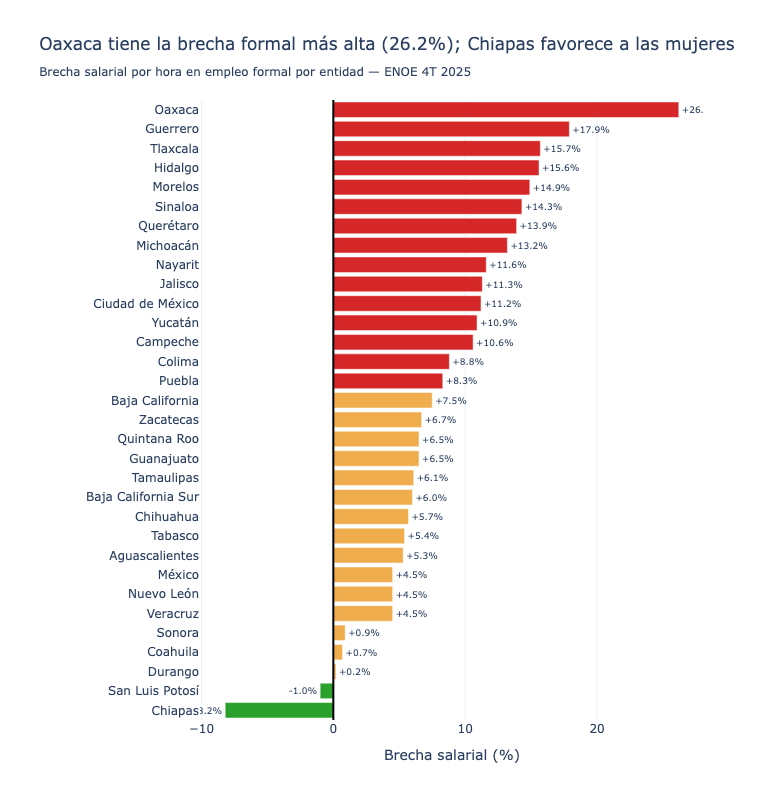

In [10]:
# Brecha por estado
rows_ent = []
for ent in d25['entidad'].unique():
    b = brecha_grupo(d25[d25['entidad'] == ent])
    rows_ent.append({'entidad': ent, **b})
df_ent = pd.DataFrame(rows_ent).dropna(subset=['brecha'])

df_ent = df_ent.sort_values('brecha', ascending=True)

colores_ent = [COLOR_VERDE if v < 0 else COLOR_AMARILLO if v < 8 else COLOR_ROJO
               for v in df_ent['brecha']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_ent['entidad'], x=df_ent['brecha'],
    orientation='h', marker_color=colores_ent,
    text=[f'{v:+.1f}%' for v in df_ent['brecha']],
    textposition='outside', textfont=dict(size=9),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha: %{x:+.1f}%<br>'
                  'Hombres: $%{customdata[0]:.0f}/hr<br>'
                  'Mujeres: $%{customdata[1]:.0f}/hr',
    customdata=df_ent[['ih','im']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

fig.update_layout(
    title='Oaxaca tiene la brecha formal más alta (26.2%); Chiapas favorece a las mujeres<br>'
          '<sub>Brecha salarial por hora en empleo formal por entidad — ENOE 4T 2025</sub>',
    template='plotly_white', height=800,
    xaxis_title='Brecha salarial (%)',
    margin=dict(l=200)
)

#fig.write_html(RUTA_SALIDA / 'g8_brecha_estados.html', include_plotlyjs='cdn')
fig.show()

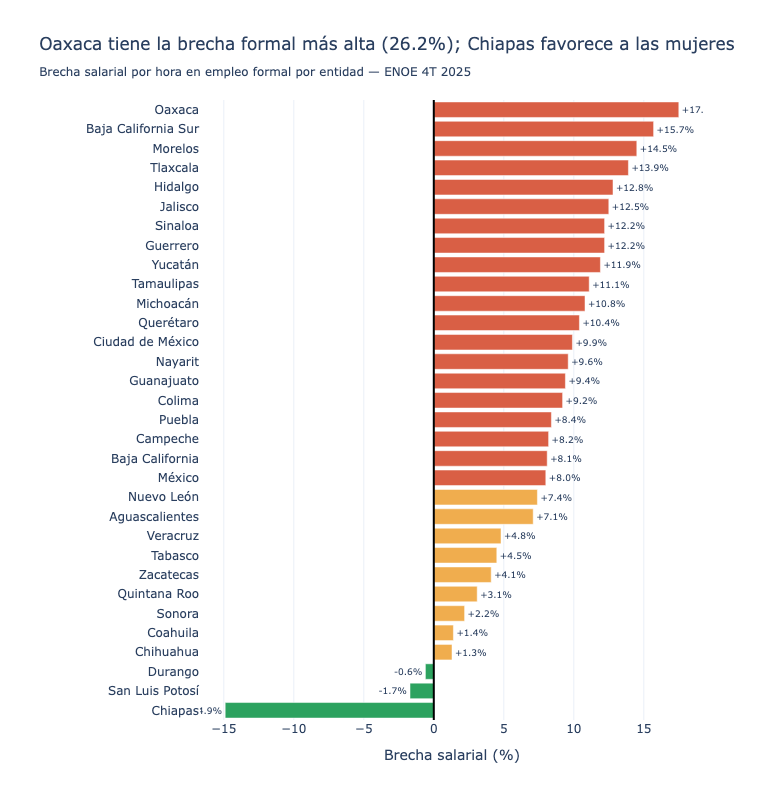

In [27]:
#DF_SI
# Brecha por estado
rows_ent = []
for ent in d25['entidad'].unique():
    b = brecha_grupo(d25[d25['entidad'] == ent])
    rows_ent.append({'entidad': ent, **b})
df_ent = pd.DataFrame(rows_ent).dropna(subset=['brecha'])

df_ent = df_ent.sort_values('brecha', ascending=True)

colores_ent = [COLOR_VERDE if v < 0 else COLOR_AMARILLO if v < 8 else COLOR_ROJO
               for v in df_ent['brecha']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_ent['entidad'], x=df_ent['brecha'],
    orientation='h', marker_color=colores_ent,
    text=[f'{v:+.1f}%' for v in df_ent['brecha']],
    textposition='outside', textfont=dict(size=9),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha: %{x:+.1f}%<br>'
                  'Hombres: $%{customdata[0]:.0f}/hr<br>'
                  'Mujeres: $%{customdata[1]:.0f}/hr',
    customdata=df_ent[['ih','im']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

fig.update_layout(
    title='Oaxaca tiene la brecha formal más alta (26.2%); Chiapas favorece a las mujeres<br>'
          '<sub>Brecha salarial por hora en empleo formal por entidad — ENOE 4T 2025</sub>',
    template='plotly_white', height=800,
    xaxis_title='Brecha salarial (%)',
    margin=dict(l=200)
)

#fig.write_html(RUTA_SALIDA / 'g8_brecha_estados.html', include_plotlyjs='cdn')
fig.show()

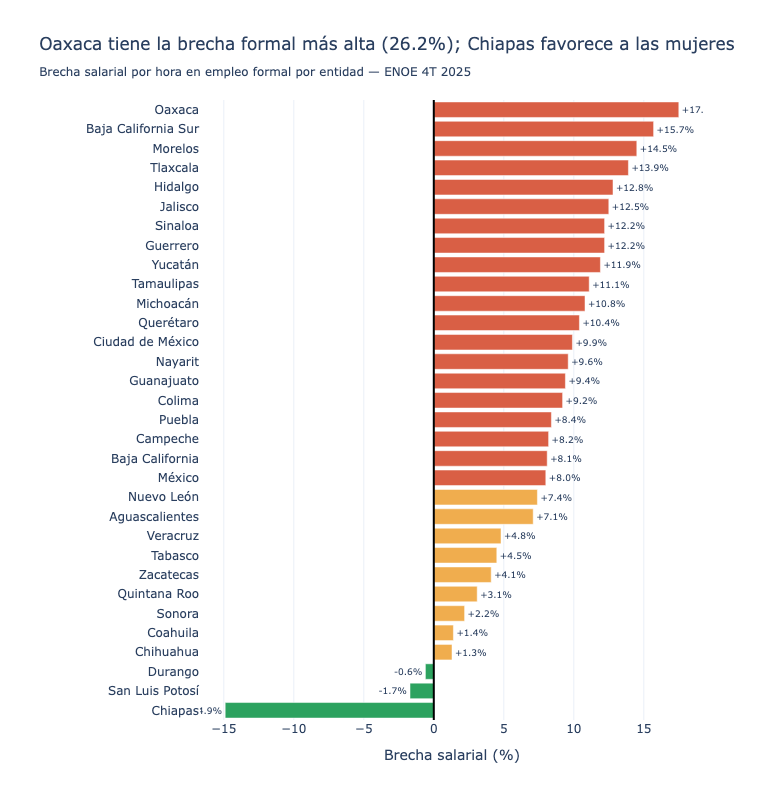

In [39]:
#DF_NO
# Brecha por estado
rows_ent = []
for ent in d25['entidad'].unique():
    b = brecha_grupo(d25[d25['entidad'] == ent])
    rows_ent.append({'entidad': ent, **b})
df_ent = pd.DataFrame(rows_ent).dropna(subset=['brecha'])

df_ent = df_ent.sort_values('brecha', ascending=True)

colores_ent = [COLOR_VERDE if v < 0 else COLOR_AMARILLO if v < 8 else COLOR_ROJO
               for v in df_ent['brecha']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_ent['entidad'], x=df_ent['brecha'],
    orientation='h', marker_color=colores_ent,
    text=[f'{v:+.1f}%' for v in df_ent['brecha']],
    textposition='outside', textfont=dict(size=9),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha: %{x:+.1f}%<br>'
                  'Hombres: $%{customdata[0]:.0f}/hr<br>'
                  'Mujeres: $%{customdata[1]:.0f}/hr',
    customdata=df_ent[['ih','im']].values
))

fig.add_vline(x=0, line_width=2, line_color='black')

fig.update_layout(
    title='Oaxaca tiene la brecha formal más alta (26.2%); Chiapas favorece a las mujeres<br>'
          '<sub>Brecha salarial por hora en empleo formal por entidad — ENOE 4T 2025</sub>',
    template='plotly_white', height=800,
    xaxis_title='Brecha salarial (%)',
    margin=dict(l=200)
)

#fig.write_html(RUTA_SALIDA / 'g8_brecha_estados.html', include_plotlyjs='cdn')
fig.show()

---
## G9 (bonus) — Heatmap sector × educación

**Hallazgo**: Manufactura sin instrucción tiene 42% de brecha — la combinación más extrema.

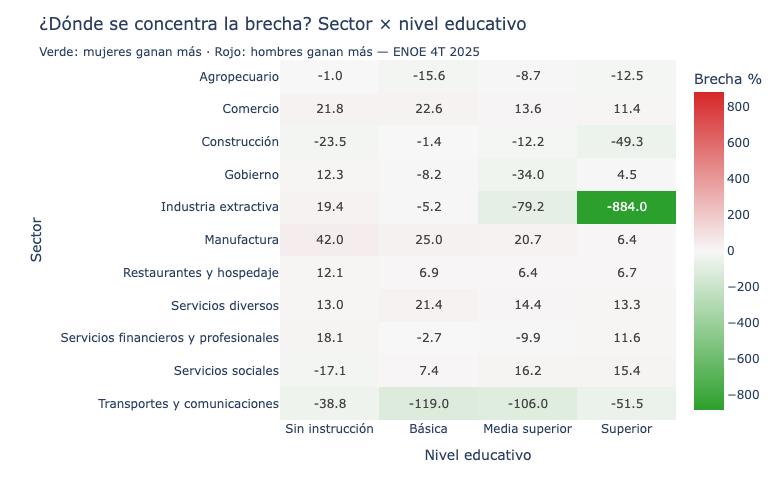

In [17]:
# Matriz sector × educación con brecha
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
rows_se = []
for sec in sorted(d25['sector'].unique()):
    for edu in orden_edu:
        sub = d25[(d25['sector']==sec) & (d25['nivel_educ']==edu)]
        b = brecha_grupo(sub)
        if pd.isna(b['brecha']): continue
        rows_se.append({'sector': sec, 'nivel_educ': edu, 'brecha': b['brecha']})

df_se = pd.DataFrame(rows_se)
pivot_se = df_se.pivot_table(index='sector', columns='nivel_educ', values='brecha')
# Reordenar columnas
pivot_se = pivot_se[[c for c in orden_edu if c in pivot_se.columns]]

fig = px.imshow(
    pivot_se.values,
    labels=dict(x='Nivel educativo', y='Sector', color='Brecha %'),
    x=pivot_se.columns.tolist(),
    y=pivot_se.index.tolist(),
    color_continuous_scale=['#2ca02c', '#f7f7f7', '#d62728'],
    color_continuous_midpoint=0,
    text_auto='.1f',
    aspect='auto'
)

fig.update_layout(
    title='¿Dónde se concentra la brecha? Sector × nivel educativo<br>'
          '<sub>Verde: mujeres ganan más · Rojo: hombres ganan más — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    margin=dict(l=280)
)

#fig.write_html(RUTA_SALIDA / 'g9_heatmap_sector_educ.html', include_plotlyjs='cdn')
fig.show()

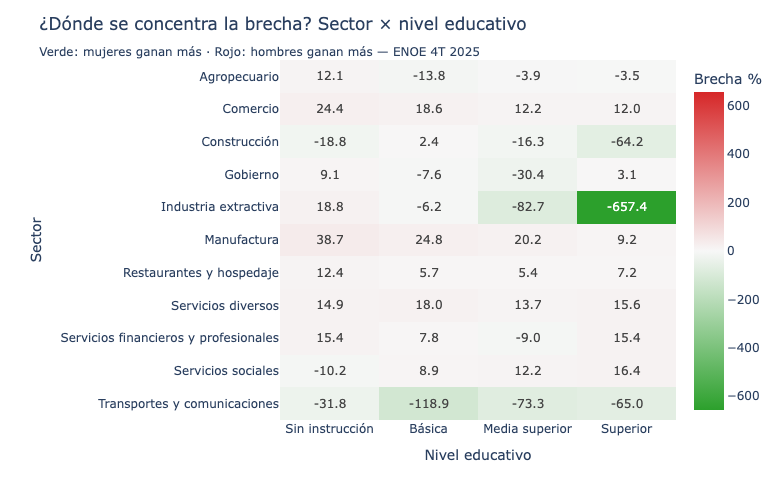

In [28]:
#DF_SI
# Matriz sector × educación con brecha
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
rows_se = []
for sec in sorted(d25['sector'].unique()):
    for edu in orden_edu:
        sub = d25[(d25['sector']==sec) & (d25['nivel_educ']==edu)]
        b = brecha_grupo(sub)
        if pd.isna(b['brecha']): continue
        rows_se.append({'sector': sec, 'nivel_educ': edu, 'brecha': b['brecha']})

df_se = pd.DataFrame(rows_se)
pivot_se = df_se.pivot_table(index='sector', columns='nivel_educ', values='brecha')
# Reordenar columnas
pivot_se = pivot_se[[c for c in orden_edu if c in pivot_se.columns]]

fig = px.imshow(
    pivot_se.values,
    labels=dict(x='Nivel educativo', y='Sector', color='Brecha %'),
    x=pivot_se.columns.tolist(),
    y=pivot_se.index.tolist(),
    color_continuous_scale=['#2ca02c', '#f7f7f7', '#d62728'],
    color_continuous_midpoint=0,
    text_auto='.1f',
    aspect='auto'
)

fig.update_layout(
    title='¿Dónde se concentra la brecha? Sector × nivel educativo<br>'
          '<sub>Verde: mujeres ganan más · Rojo: hombres ganan más — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    margin=dict(l=280)
)

#fig.write_html(RUTA_SALIDA / 'g9_heatmap_sector_educ.html', include_plotlyjs='cdn')
fig.show()

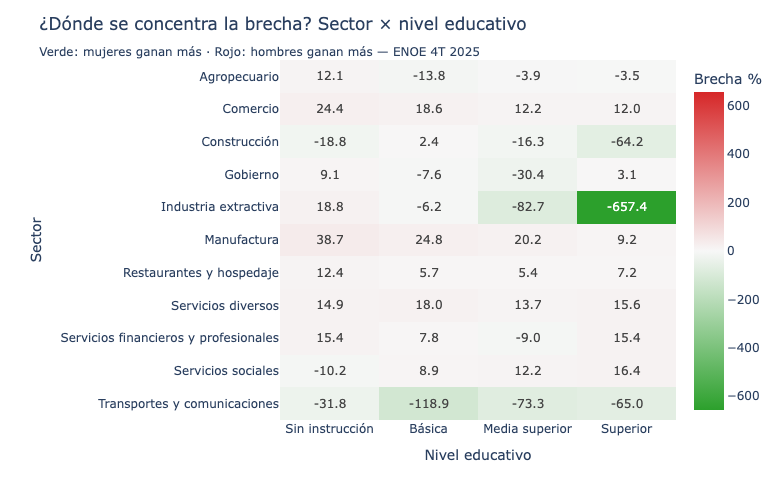

In [40]:
#DF_NO
# Matriz sector × educación con brecha
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
rows_se = []
for sec in sorted(d25['sector'].unique()):
    for edu in orden_edu:
        sub = d25[(d25['sector']==sec) & (d25['nivel_educ']==edu)]
        b = brecha_grupo(sub)
        if pd.isna(b['brecha']): continue
        rows_se.append({'sector': sec, 'nivel_educ': edu, 'brecha': b['brecha']})

df_se = pd.DataFrame(rows_se)
pivot_se = df_se.pivot_table(index='sector', columns='nivel_educ', values='brecha')
# Reordenar columnas
pivot_se = pivot_se[[c for c in orden_edu if c in pivot_se.columns]]

fig = px.imshow(
    pivot_se.values,
    labels=dict(x='Nivel educativo', y='Sector', color='Brecha %'),
    x=pivot_se.columns.tolist(),
    y=pivot_se.index.tolist(),
    color_continuous_scale=['#2ca02c', '#f7f7f7', '#d62728'],
    color_continuous_midpoint=0,
    text_auto='.1f',
    aspect='auto'
)

fig.update_layout(
    title='¿Dónde se concentra la brecha? Sector × nivel educativo<br>'
          '<sub>Verde: mujeres ganan más · Rojo: hombres ganan más — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    margin=dict(l=280)
)

#fig.write_html(RUTA_SALIDA / 'g9_heatmap_sector_educ.html', include_plotlyjs='cdn')
fig.show()

---
## G10 (bonus) — Techo de cristal: mujeres directivas por sector

**Hallazgo**: Servicios diversos, el sector con más directivos, tiene solo 17.9% de mujeres.

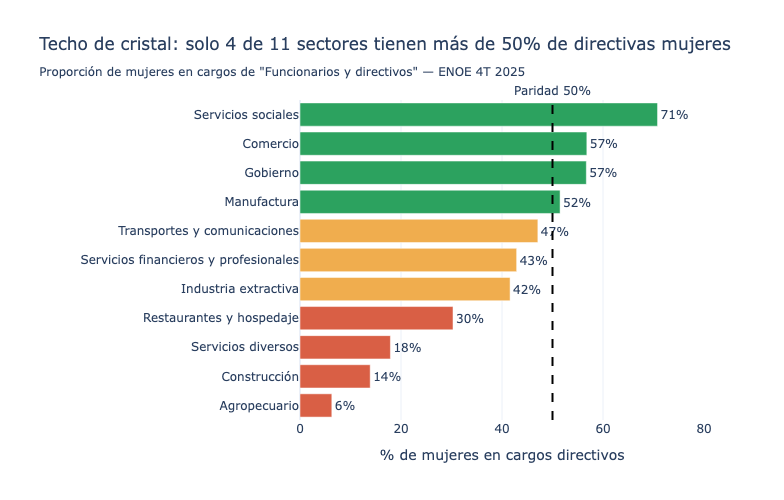

In [14]:
# Proporción de mujeres en cargos directivos por sector
directivos = d25[d25['ocupacion'] == 'Funcionarios y directivos']
rows_dir = []
for sec in directivos['sector'].unique():
    ds = directivos[directivos['sector'] == sec]
    total = ds['poblacion_ocupada'].sum()
    if total < 5000: continue
    mujeres = ds[ds['sexo']=='Mujer']['poblacion_ocupada'].sum()
    rows_dir.append({'sector': sec, 'pct_mujeres': round(mujeres/total*100, 1), 'total': total})

df_dir = pd.DataFrame(rows_dir).sort_values('pct_mujeres', ascending=True)

colores_dir = [COLOR_VERDE if v >= 50 else COLOR_AMARILLO if v >= 35 else COLOR_ROJO
               for v in df_dir['pct_mujeres']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_dir['sector'], x=df_dir['pct_mujeres'],
    orientation='h', marker_color=colores_dir,
    text=[f'{v:.0f}%' for v in df_dir['pct_mujeres']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Mujeres directivas: %{x:.1f}%<br>'
                  'Total directivos: %{customdata[0]:,.0f}',
    customdata=df_dir[['total']].values
))

fig.add_vline(x=50, line_dash='dash', line_color='black',
              annotation_text='Paridad 50%', annotation_position='top')

fig.update_layout(
    title='Techo de cristal: solo 4 de 11 sectores tienen más de 50% de directivas mujeres<br>'
          '<sub>Proporción de mujeres en cargos de "Funcionarios y directivos" — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    xaxis_title='% de mujeres en cargos directivos',
    xaxis_range=[0, 80],
    margin=dict(l=300)
)

#fig.write_html(RUTA_SALIDA / 'g10_techo_cristal.html', include_plotlyjs='cdn')
fig.show()

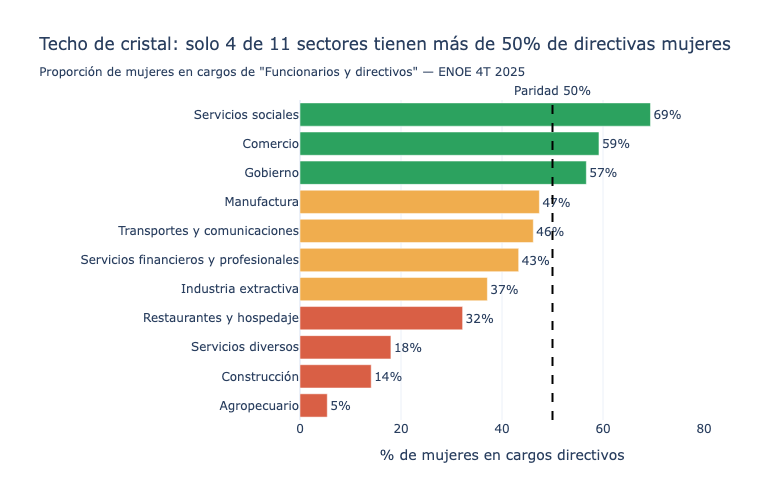

In [29]:
#DF_SI
# Proporción de mujeres en cargos directivos por sector
directivos = d25[d25['ocupacion'] == 'Funcionarios y directivos']
rows_dir = []
for sec in directivos['sector'].unique():
    ds = directivos[directivos['sector'] == sec]
    total = ds['poblacion_ocupada'].sum()
    if total < 5000: continue
    mujeres = ds[ds['sexo']=='Mujer']['poblacion_ocupada'].sum()
    rows_dir.append({'sector': sec, 'pct_mujeres': round(mujeres/total*100, 1), 'total': total})

df_dir = pd.DataFrame(rows_dir).sort_values('pct_mujeres', ascending=True)

colores_dir = [COLOR_VERDE if v >= 50 else COLOR_AMARILLO if v >= 35 else COLOR_ROJO
               for v in df_dir['pct_mujeres']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_dir['sector'], x=df_dir['pct_mujeres'],
    orientation='h', marker_color=colores_dir,
    text=[f'{v:.0f}%' for v in df_dir['pct_mujeres']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Mujeres directivas: %{x:.1f}%<br>'
                  'Total directivos: %{customdata[0]:,.0f}',
    customdata=df_dir[['total']].values
))

fig.add_vline(x=50, line_dash='dash', line_color='black',
              annotation_text='Paridad 50%', annotation_position='top')

fig.update_layout(
    title='Techo de cristal: solo 4 de 11 sectores tienen más de 50% de directivas mujeres<br>'
          '<sub>Proporción de mujeres en cargos de "Funcionarios y directivos" — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    xaxis_title='% de mujeres en cargos directivos',
    xaxis_range=[0, 80],
    margin=dict(l=300)
)

#fig.write_html(RUTA_SALIDA / 'g10_techo_cristal.html', include_plotlyjs='cdn')
fig.show()

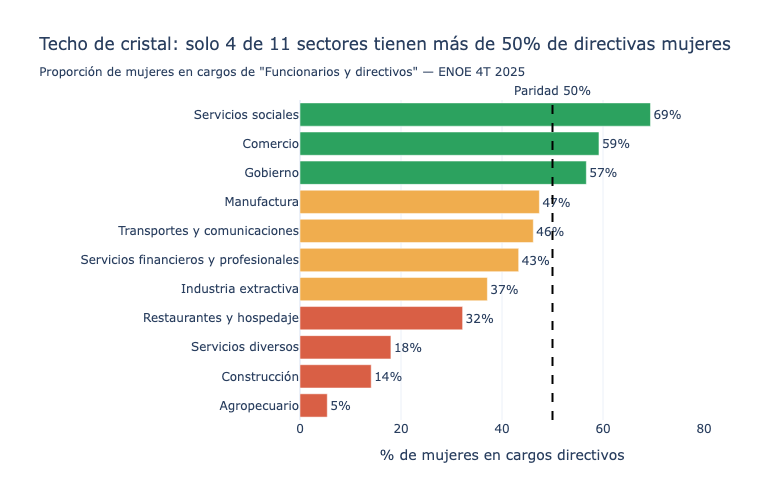

In [41]:
#DF_NO
# Proporción de mujeres en cargos directivos por sector
directivos = d25[d25['ocupacion'] == 'Funcionarios y directivos']
rows_dir = []
for sec in directivos['sector'].unique():
    ds = directivos[directivos['sector'] == sec]
    total = ds['poblacion_ocupada'].sum()
    if total < 5000: continue
    mujeres = ds[ds['sexo']=='Mujer']['poblacion_ocupada'].sum()
    rows_dir.append({'sector': sec, 'pct_mujeres': round(mujeres/total*100, 1), 'total': total})

df_dir = pd.DataFrame(rows_dir).sort_values('pct_mujeres', ascending=True)

colores_dir = [COLOR_VERDE if v >= 50 else COLOR_AMARILLO if v >= 35 else COLOR_ROJO
               for v in df_dir['pct_mujeres']]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_dir['sector'], x=df_dir['pct_mujeres'],
    orientation='h', marker_color=colores_dir,
    text=[f'{v:.0f}%' for v in df_dir['pct_mujeres']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Mujeres directivas: %{x:.1f}%<br>'
                  'Total directivos: %{customdata[0]:,.0f}',
    customdata=df_dir[['total']].values
))

fig.add_vline(x=50, line_dash='dash', line_color='black',
              annotation_text='Paridad 50%', annotation_position='top')

fig.update_layout(
    title='Techo de cristal: solo 4 de 11 sectores tienen más de 50% de directivas mujeres<br>'
          '<sub>Proporción de mujeres en cargos de "Funcionarios y directivos" — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    xaxis_title='% de mujeres en cargos directivos',
    xaxis_range=[0, 80],
    margin=dict(l=300)
)

#fig.write_html(RUTA_SALIDA / 'g10_techo_cristal.html', include_plotlyjs='cdn')
fig.show()

---
## Resumen de gráficas generadas

| # | Archivo | Hallazgo principal | Para la rúbrica |
|---|---------|-------------------|------------------|
| G1 | `g1_serie_temporal.html` | Brecha bajó de 11.5% a 6.6% en 20 años | Hilo conductor (C2) |
| G2 | `g2_brecha_sector.html` | 3 sectores donde mujeres ganan más | Visibilización (I3) |
| G3 | `g3_feminizacion_vs_brecha.html` | Más mujeres ≠ menos brecha | Momento memorable (C4) |
| G4 | `g4_brecha_sector_temporal.html` | Manufactura mejoró pero sigue peor | Hilo conductor (C2) |
| G5 | `g5_brecha_educacion.html` | Educación reduce pero no elimina | Evidencia (I2) |
| G6 | `g6_cambio_ocupacion.html` | Techo de cristal EMPEORÓ en 20 años | Momento memorable (C4) |
| G7 | `g7_brecha_estructural.html` | 58% de celdas con hombres ganando más | Evidencia (I2) |
| G8 | `g8_brecha_estados.html` | Oaxaca 26.2%, Chiapas -8.2% | Pertinencia territorial (I1) |
| G9 | `g9_heatmap_sector_educ.html` | Manufactura sin instrucción = 42% | Poblaciones afectadas (I5) |
| G10 | `g10_techo_cristal.html` | Solo 4/11 sectores con paridad directiva | Originalidad (C3) |

In [ ]:
# Listar archivos generados
print('Archivos HTML generados en dashboard/:')
for f in sorted(RUTA_SALIDA.glob('g*.html')):
    kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} {kb:.0f} KB')